In [1]:
import os
os.chdir("..")
os.listdir()

['.git',
 '.gitignore',
 '.venv',
 'data',
 'models',
 'notebooks',
 'pyproject.toml',
 'README.md',
 'references',
 'reports',
 'src']

### Data Loading and Transformation

In [ ]:
import torch
import numpy as np
import torch.nn as nn

from torchvision import datasets, transforms
from torch.utils.data import DataLoader, Subset, WeightedRandomSampler
from sklearn.model_selection import train_test_split

from src.config import DATA_DIR

DATA_MINI = DATA_DIR / "data_mini"

def get_defect_loaders(batch_size=32):
    
    # Train gets the heavy augmentation to prevent overfitting
    train_transform = transforms.Compose([
        transforms.RandomResizedCrop(224),
        transforms.RandomHorizontalFlip(),
        transforms.RandomRotation(15),
        transforms.ColorJitter(brightness=0.2, contrast=0.2, saturation=0.2),
        transforms.GaussianBlur(kernel_size=3),
        transforms.ToTensor(),
        transforms.Normalize([0.485, 0.456, 0.406], [0.229, 0.224, 0.225])
    ])

    # Val/Test strictly gets resized and normalized
    eval_transform = transforms.Compose([
        transforms.Resize((224, 224)),
        transforms.ToTensor(),
        transforms.Normalize([0.485, 0.456, 0.406], [0.229, 0.224, 0.225])
    ])

    dataset_train = datasets.ImageFolder(DATA_MINI, transform=train_transform)
    dataset_eval = datasets.ImageFolder(DATA_MINI, transform=eval_transform)
    
    indices = np.arange(len(dataset_train))
    targets = dataset_train.targets

    # Stratified splits to ensure proportional representation before sampling
    train_idx, temp_idx = train_test_split(indices, train_size=0.7, stratify=targets, random_state=1)
    
    temp_targets = [targets[i] for i in temp_idx]
    val_idx, test_idx = train_test_split(temp_idx, train_size=0.5, stratify=temp_targets, random_state=1)

    # Map the subsets to the correct underlying dataset
    train_set = Subset(dataset_train, train_idx)
    val_set = Subset(dataset_eval, val_idx)
    test_set = Subset(dataset_eval, test_idx)

    # Build the WeightedRandomSampler for the Train Loader
    train_targets = [targets[i] for i in train_idx]
    class_counts = np.bincount(train_targets)
    
    # Weight per class = 1 / number of samples in that class
    class_weights = 1. / class_counts
    
    # Assign the correct weight to every individual sample in the training set
    sample_weights = np.array([class_weights[t] for t in train_targets])
    sample_weights = torch.from_numpy(sample_weights).double()
    
    sampler = WeightedRandomSampler(weights=sample_weights, num_samples=len(sample_weights), replacement=True)

    # Create DataLoaders
    train_loader = DataLoader(train_set, batch_size=batch_size, sampler=sampler, num_workers=4, pin_memory=True)
    val_loader = DataLoader(val_set, batch_size=batch_size, shuffle=False, num_workers=4, pin_memory=True)
    test_loader = DataLoader(test_set, batch_size=batch_size, shuffle=False, num_workers=4, pin_memory=True)

    return train_loader, val_loader, test_loader, len(train_idx), len(val_idx), len(test_idx), train_set

train_loader, val_loader, test_loader, n_train, n_val, n_test, train_set = get_defect_loaders()
print(f"Total: {n_train + n_val + n_test}")
print(f"Training: {n_train} | Validation: {n_val} | Test: {n_test}")

Total: 1800
Training: 1260 | Validation: 270 | Test: 270


### Baselines

#### Baseline w/o PCA (Random Forest)

In [ ]:
import matplotlib.pyplot as plt
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix
import seaborn as sns

class_names = sorted(os.listdir(DATA_MINI)) 

def train_ml(mdl, train_loader, val_loader, class_names):
    print(f"Extracting features for {mdl.__class__.__name__}...")
    
    def extract_features(loader):
        features = []
        labels = []
        for images, targets in loader:
            images_flat = images.view(images.size(0), -1).numpy()
            features.append(images_flat)
            labels.append(targets.numpy())
            
        return np.vstack(features), np.concatenate(labels)

    # Extract and flatten data
    X_train, y_train = extract_features(train_loader)
    X_val, y_val = extract_features(val_loader)

    print(f"Training {mdl.__class__.__name__}... (High dimensionality: {X_train.shape[1]} features)")
    mdl.fit(X_train, y_train)

    print("Evaluating...")
    val_preds = mdl.predict(X_val)
    val_acc = accuracy_score(y_val, val_preds)

    print(f"Validation Accuracy: {val_acc:.4f}")
    print("\nValidation Classification Report:")
    print(classification_report(y_val, val_preds, target_names=class_names))
    
    # Confusion Matrix 
    plt.figure(figsize=(10, 8))
    cm = confusion_matrix(y_val, val_preds)
    cm_perc = cm.astype('float') / cm.sum(axis=1)[:, np.newaxis]
    sns.heatmap(cm_perc, annot=True, fmt='.2f', cmap='Blues', xticklabels=class_names, yticklabels=class_names)
    plt.title(f"Baseline: {mdl.__class__.__name__} Normalized Confusion Matrix")
    plt.xlabel('Predicted Label')
    plt.ylabel('True Label')
    plt.show()
    
    return mdl

Extracting features for RandomForestClassifier...
Training RandomForestClassifier... (High dimensionality: 150528 features)
Evaluating...
Validation Accuracy: 0.5630

Validation Classification Report:
              precision    recall  f1-score   support

       brick       0.62      0.60      0.61        30
         cob       0.39      0.37      0.38        30
    concrete       0.52      0.50      0.51        30
       decks       0.47      0.60      0.53        30
   pavements       0.65      0.50      0.57        30
        road       0.76      0.73      0.75        30
       stone       0.45      0.50      0.48        30
        tile       0.78      0.60      0.68        30
       walls       0.53      0.67      0.59        30

    accuracy                           0.56       270
   macro avg       0.58      0.56      0.56       270
weighted avg       0.58      0.56      0.56       270



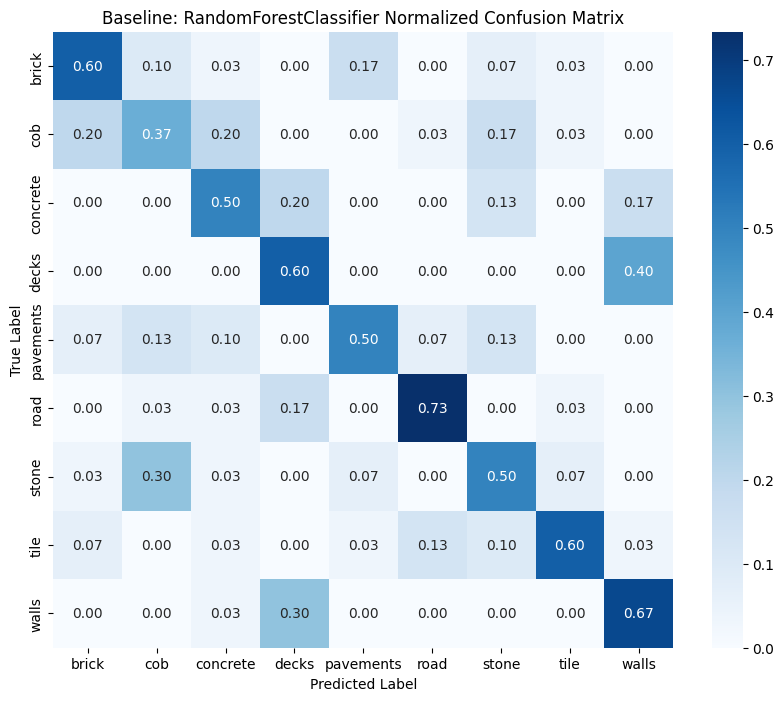

In [5]:
from sklearn.ensemble import RandomForestClassifier
rf_model = RandomForestClassifier(n_estimators=50, n_jobs=-1, random_state=42)
trained_rf = train_ml(rf_model, train_loader, val_loader, class_names)

#### Baseline w/ PCA (Random Forest)

In [ ]:
from sklearn.decomposition import PCA
from sklearn.metrics import confusion_matrix, classification_report

import matplotlib.pyplot as plt
import seaborn as sns

def train_ml_with_pca(ml_model, train_loader, val_loader, class_names, n_components=100):
    print("Extracting and flattening image features...")
    
    def extract_features(loader):
        features, labels = [], []
        for images, targets in loader:
            images_flat = images.view(images.size(0), -1).numpy()
            features.append(images_flat)
            labels.append(targets.numpy())
        return np.vstack(features), np.concatenate(labels)

    X_train, y_train = extract_features(train_loader)
    X_val, y_val = extract_features(val_loader)

    pca = PCA(n_components=n_components, random_state=42)
    X_train_pca = pca.fit_transform(X_train)
    X_val_pca = pca.transform(X_val)

    ml_model.fit(X_train_pca, y_train)
    val_preds = ml_model.predict(X_val_pca)

    plt.figure(figsize=(10, 8))
    cm = confusion_matrix(y_val, val_preds)
    cm_perc = cm.astype('float') / cm.sum(axis=1)[:, np.newaxis] 
    sns.heatmap(cm_perc, annot=True, fmt='.2f', cmap='Blues', xticklabels=class_names, yticklabels=class_names)
    plt.title(f"Baseline: {ml_model.__class__.__name__} Normalized Confusion Matrix")
    plt.xlabel('Predicted Label')
    plt.ylabel('True Label')
    plt.show()

    return ml_model, pca
    
def plot_pca_variance(pca):
    """Graphs the cumulative explained variance of the PCA components."""
    plt.figure(figsize=(8, 4))
    plt.plot(np.cumsum(pca.explained_variance_ratio_), marker='o', linestyle='--')
    plt.title('PCA Cumulative Explained Variance')
    plt.xlabel('Number of Components')
    plt.ylabel('Cumulative Explained Variance')
    plt.grid(True)
    plt.show()

Extracting and flattening image features...


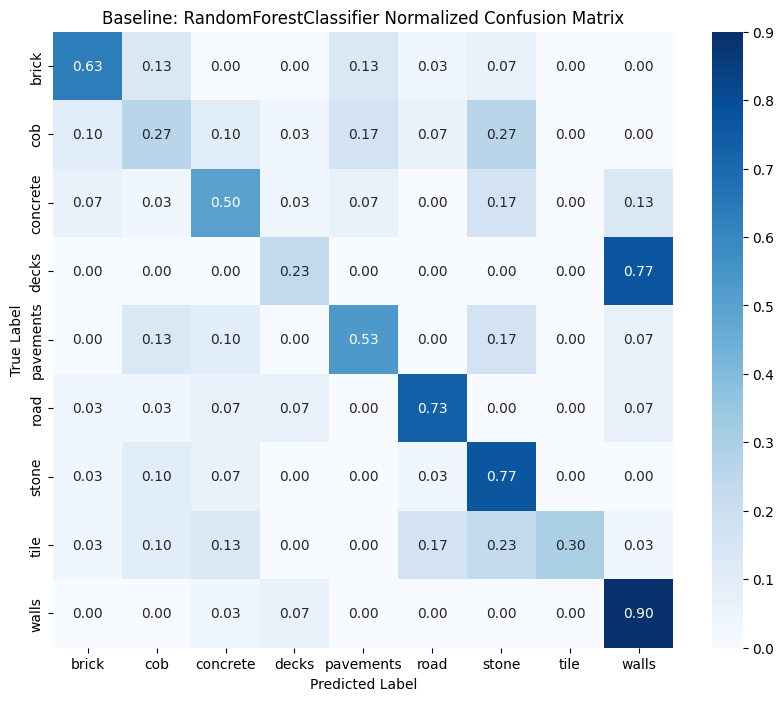

In [7]:
from sklearn.ensemble import RandomForestClassifier
rf_model = RandomForestClassifier(n_estimators=100, n_jobs=-1, random_state=42)
trained_model, fitted_pca = train_ml_with_pca(rf_model, train_loader, val_loader, class_names, n_components=150)

### Primary Model: Custom Deep Learning Architecture (CNN)

In [8]:
import matplotlib.pyplot as plt
from torchvision import models

def train_dl(mdl, train_loader, val_loader, lr=0.001, epochs=20):
    device = next(mdl.parameters()).device
    
    criterion = nn.CrossEntropyLoss()
    optimizer = torch.optim.Adam(mdl.parameters(), lr=lr)

    train_acc, val_acc = [], []
    train_loss, val_loss = [], []
    
    print(f"Starting Training on {device}...")
    
    for epoch in range(epochs):
        
        # Training Phase
        mdl.train()
        running_loss = 0
        correct = 0
        total= 0

        for images, labels in train_loader:
            images, labels = images.to(device), labels.to(device)

            # Forward pass
            outputs = mdl(images)
            loss = criterion(outputs, labels)

            # Backward pass
            optimizer.zero_grad()
            loss.backward() 
            optimizer.step()           

            running_loss += loss.item()
            pred = outputs.argmax(dim=1, keepdim=True)
            correct += pred.eq(labels.view_as(pred)).sum().item()
            total += images.size(0)

        # Validation Phase
        mdl.eval()
        v_loss = 0.0
        v_correct = 0
        v_total = 0

        with torch.no_grad(): 
            for images, labels in val_loader:
                images, labels = images.to(device), labels.to(device)

                outputs = mdl(images)
                loss = criterion(outputs, labels)

                v_loss += loss.item()
                pred = outputs.argmax(dim=1, keepdim=True)
                v_correct += pred.eq(labels.view_as(pred)).sum().item()
                v_total += images.size(0)

        train_acc.append(correct / total)
        val_acc.append(v_correct / v_total)
        train_loss.append(running_loss / len(train_loader))
        val_loss.append(v_loss / len(val_loader))

    return train_acc, val_acc, train_loss, val_loss
    
def vizualize(train_acc, val_acc, train_loss, val_loss):
    epochs_range = range(1, len(train_acc) + 1)

    plt.figure(figsize=(12, 5))

    # Loss
    plt.subplot(1, 2, 1)
    plt.plot(epochs_range, train_loss, label='Training Loss', color='blue', marker='o')
    plt.plot(epochs_range, val_loss, label='Validation Loss', color='red', marker='x')
    plt.title('Loss vs. Epochs')
    plt.xlabel('Epochs')
    plt.ylabel('Loss')
    plt.legend()
    plt.grid(True)

    # Accuracy
    plt.subplot(1, 2, 2)
    plt.plot(epochs_range, train_acc, label='Training Acc', color='blue', marker='o')
    plt.plot(epochs_range, val_acc, label='Validation Acc', color='red', marker='x')
    plt.title('Accuracy vs. Epochs')
    plt.xlabel('Epochs')
    plt.ylabel('Accuracy')
    plt.legend()
    plt.grid(True)

    plt.tight_layout()
    plt.show()

SurfaceDefectCNN(
  (conv1): Conv2d(3, 16, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
  (conv2): Conv2d(16, 32, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
  (conv3): Conv2d(32, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
  (conv4): Conv2d(64, 128, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
  (fc1): Linear(in_features=25088, out_features=512, bias=True)
  (fc2): Linear(in_features=512, out_features=9, bias=True)
  (pool): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
  (drop): Dropout(p=0.5, inplace=False)
)
Starting Training on cuda:0...


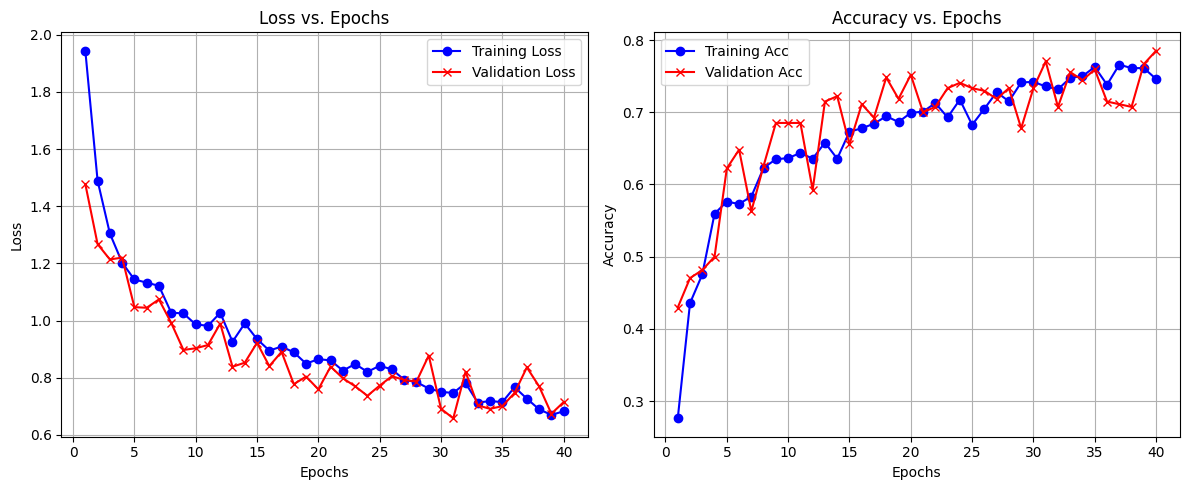

In [ ]:
import torch.nn.functional as F

class SurfaceDefectCNN(nn.Module):
    def __init__(self, num_classes=9):
        super().__init__()
        self.name = "ASLClassifier"
        self.conv1 = nn.Conv2d(in_channels=3, out_channels=16, kernel_size=3, padding=1) 
        self.conv2 = nn.Conv2d(16, 32, 3, padding=1)        
        self.conv3 = nn.Conv2d(32, 64, 3, padding=1)        
        self.conv4 = nn.Conv2d(64, 128, 3, padding=1)
        self.fc1 = nn.Linear(128 * 14 * 14, 512)
        self.fc2 = nn.Linear(512, num_classes) # num_classes = 9 (A-I)
        self.pool = nn.MaxPool2d(kernel_size=2, stride=2)
        self.drop = nn.Dropout(0.5)

    def forward(self, x):
        x = self.pool(F.relu(self.conv1(x)))
        x = self.pool(F.relu(self.conv2(x)))
        x = self.pool(F.relu(self.conv3(x)))
        x = self.pool(F.relu(self.conv4(x)))
        x = torch.flatten(x, 1)
        x = self.drop(F.relu(self.fc1(x)))
        x = self.fc2(x) # Logits
        return x
    
primary_model = SurfaceDefectCNN(num_classes=9).to("cuda")
print(primary_model)

train_acc, val_acc, train_loss, val_loss = train_dl(
    mdl=primary_model, 
    train_loader=train_loader, 
    val_loader=val_loader, 
    lr=0.0001, 
    epochs=40  
)

vizualize(train_acc, val_acc, train_loss, val_loss)

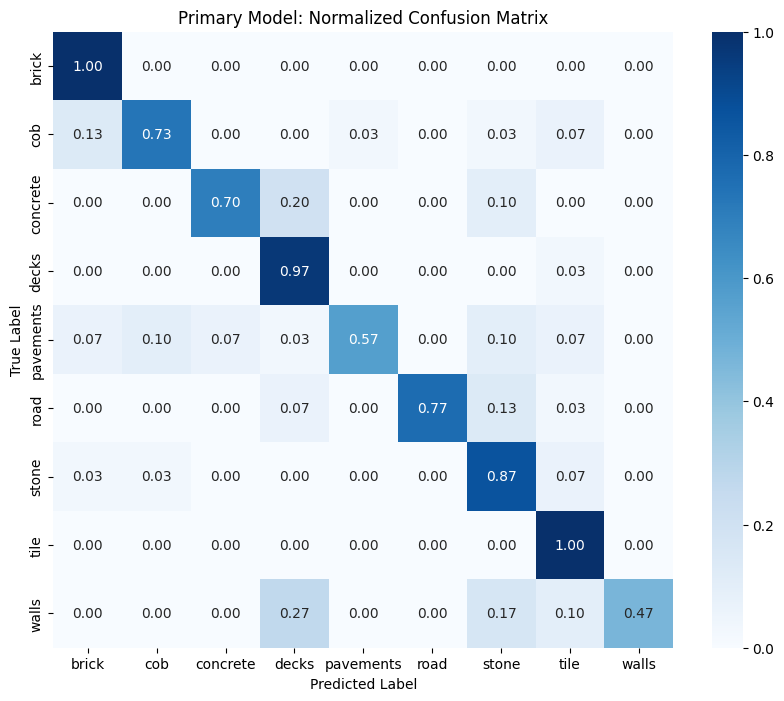


Final Classification Report:
              precision    recall  f1-score   support

       brick       0.81      1.00      0.90        30
         cob       0.85      0.73      0.79        30
    concrete       0.91      0.70      0.79        30
       decks       0.63      0.97      0.76        30
   pavements       0.94      0.57      0.71        30
        road       1.00      0.77      0.87        30
       stone       0.62      0.87      0.72        30
        tile       0.73      1.00      0.85        30
       walls       1.00      0.47      0.64        30

    accuracy                           0.79       270
   macro avg       0.83      0.79      0.78       270
weighted avg       0.83      0.79      0.78       270



In [ ]:
import seaborn as sns
from sklearn.metrics import confusion_matrix, classification_report

def plot_final_confusion_matrix(model, loader, device, class_names):
    model.eval()
    all_preds = []
    all_labels = []
    
    with torch.no_grad():
        for images, labels in loader:
            images = images.to(device)
            outputs = model(images)
            preds = torch.argmax(outputs, dim=1)
            
            all_preds.extend(preds.cpu().numpy())
            all_labels.extend(labels.numpy())
    
    # Matrix
    cm = confusion_matrix(all_labels, all_preds)
    cm_perc = cm.astype('float') / cm.sum(axis=1)[:, np.newaxis]
    plt.figure(figsize=(10, 8))
    sns.heatmap(cm_perc, annot=True, fmt='.2f', cmap='Blues', xticklabels=class_names, yticklabels=class_names)
    plt.title('Primary Model: Normalized Confusion Matrix')
    plt.xlabel('Predicted Label')
    plt.ylabel('True Label')
    plt.show()
    
    print("\nFinal Classification Report:")
    print(classification_report(all_labels, all_preds, target_names=class_names))

class_names = sorted(os.listdir(DATA_MINI)) 
plot_final_confusion_matrix(primary_model, val_loader, "cuda", class_names)